# Project Additional Materials — Monthly AutoML Test Results

- Student ID: 10841269  
- Course Code: DATA70132  
- Academic Year: 2024–25  

**Environment:** See `README` and `ERP_Environment_2025.yaml`.  
**Reproduction:** Run this notebook top to bottom in the same folder as the trained model files (`automl_training_monthly.pkl`, `xgb_monthly.pkl`, `rf_monthly.pkl`, `lgb_monthly.pkl`) and `All_UKonly_monthly_cleaned.nc`.  

This notebook loads trained AutoML models and reports monthly test results (metrics and maps).


## Step 0 — Import required libraries


In [44]:
import pandas as pd
import numpy as np
import pickle
import xarray as xr
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import cartopy.crs as ccrs, cartopy.feature as cfeature

## Step 1 — Load monthly dataset & define test windows


In [ ]:
# Load the dataset
ds = xr.open_dataset("All_UKonly_monthly_cleaned.nc", decode_times=False)
df = ds.to_dataframe().dropna().reset_index()

# Time split
df_test1   = df[(df["year_month"] >= 202101) & (df["year_month"] <= 203012)]
df_test2  = df[(df["year_month"] >= 202101) & (df["year_month"] <= 202112)]
df_test3  = df[(df["year_month"] >= 202101) & (df["year_month"] <= 202212)]
df_test4  = df[(df["year_month"] >= 206901) & (df["year_month"] <= 206912)]
df_test5  = df[(df["year_month"] >= 206901) & (df["year_month"] <= 207012)]
df_test6  = df[(df["year_month"] >= 203101) & (df["year_month"] <= 208012)]
df_test7  = df[(df["year_month"] >= 202101) & (df["year_month"] <= 208012)]

features = ["TREFHT", "FLNS", "FSNS", "QBOT", "UBOT", "VBOT", "PRECT", "PRSN"]
target = "TREFMXAV_U"

X_test1, y_test1 = df_test1[features], df_test1[target]
X_test2, y_test2 = df_test2[features], df_test2[target]
X_test3, y_test3 = df_test3[features], df_test3[target]
X_test4, y_test4 = df_test4[features], df_test4[target]
X_test5, y_test5 = df_test5[features], df_test5[target]
X_test6, y_test6 = df_test6[features], df_test6[target]
X_test7, y_test7 = df_test7[features], df_test7[target]

# Evaluate the model
def evaluate(model_path,X, y, label):
    # Load the pre-trained AutoML model
    with open(model_path, "rb") as f:
        model = pickle.load(f)
    preds = model.predict(X)
    rmse = mean_squared_error(y, preds, squared=False)
    r2 = r2_score(y, preds)

    # Print evaluation results
    print(f"{label} - R²: {r2:.4f}, RMSE: {rmse:.4f}")
    
    return ( r2, rmse)

def plot_time_series(model_path, X, y, df_test, label):
    # Load model and predict
    with open(model_path, "rb") as f:
        model = pickle.load(f)
    preds = model.predict(X)

    # Build result DataFrame including simulation ID
    res = df_test[["year_month", "lat", "lon", "sim"]].copy()
    res["t"] = y.values
    res["p"] = preds

    # Ensemble mean
    ts_true = res.groupby(["year_month","sim"])["t"].mean().groupby("year_month").mean()
    ts_pred = res.groupby(["year_month","sim"])["p"].mean().groupby("year_month").mean()

    # Plot
    plt.figure(figsize=(10,5))
    plt.plot(ts_true.index, ts_true.values, label="True", color="black")
    plt.plot(ts_pred.index, ts_pred.values, label="Predicted", color="red", linestyle="--")
    plt.title(f"Time Series — {label}")
    plt.xlabel("Year-Month")
    plt.ylabel("Temperature")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_map(model_path, X, y, df_test, label, kind="residual",
             extent_uk=[-8, 2.5, 49.5, 60],
             vmin=None, vmax=None):
    with open(model_path, "rb") as f:
        model = pickle.load(f)
    preds = model.predict(X)

    r = df_test[["lat","lon","sim"]].copy()
    r["t"] = y.values
    r["p"] = preds

    if kind=="true":
        s = r.groupby(["lat","lon","sim"])["t"].mean().groupby(["lat","lon"]).mean()
        title, cmap = f"Ensemble Mean True — {label}", "viridis"
    elif kind=="pred":
        s = r.groupby(["lat","lon","sim"])["p"].mean().groupby(["lat","lon"]).mean()
        title, cmap = f"Ensemble Mean Pred — {label}", "viridis"
    elif kind=="residual":
        s = (r["p"]-r["t"]).groupby([r["lat"],r["lon"],r["sim"]]).mean().groupby(["lat","lon"]).mean()
        title, cmap = f"Ensemble Mean Residual — {label}", "coolwarm"
    elif kind=="rmse":
        rmse = r.groupby(["lat","lon","sim"]).apply(lambda g: np.sqrt(np.mean((g["p"]-g["t"])**2)))
        s = rmse.groupby(["lat","lon"]).mean()
        title, cmap = f"Ensemble Mean RMSE — {label}", "Reds"
    else:
        raise ValueError("kind must be 'true'|'pred'|'residual'|'rmse'")

    # 2D grid
    grid = s.unstack().sort_index(axis=0).sort_index(axis=1)
    lats, lons, data = grid.index.values, grid.columns.values, grid.values

    # plot
    fig, ax = plt.subplots(figsize=(8,6), subplot_kw={"projection": ccrs.PlateCarree()}, layout="constrained")
    im = ax.pcolormesh(lons, lats, data, cmap=cmap, shading="auto", vmin=vmin, vmax=vmax)
    ax.set_extent(extent_uk, crs=ccrs.PlateCarree())
    ax.coastlines("10m"); ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.6)

    gl = ax.gridlines(draw_labels=True, x_inline=False, y_inline=False,
                      linewidth=0.3, color="gray", alpha=0.5)
    gl.right_labels = False
    gl.top_labels = False

    fig.colorbar(im, ax=ax, orientation="vertical", shrink=0.9, pad=0.06)
    ax.set_title(title); plt.show()

def rmse_grid(model_path, X, y, df_test):
    with open(model_path, "rb") as f:
        model = pickle.load(f)
    p = model.predict(X)
    r = df_test[["lat","lon","sim"]].copy()
    r["t"] = y.values; r["p"] = p
    rmse = r.groupby(["lat","lon","sim"]).apply(
        lambda g: np.sqrt(np.mean((g["p"]-g["t"])**2))
    ).groupby(["lat","lon"]).mean().unstack().sort_index(axis=0).sort_index(axis=1)
    return rmse.values  # 2D array


## Step 2 — Evaluate Baseline AutoML model


In [ ]:
# Baseline model evaluation
evaluate("automl_training_monthly.pkl", X_test1, y_test1, "XGBoost_Monthly_2021_2030_Baseline")
evaluate("automl_training_monthly.pkl", X_test2, y_test2, "XGBoost_Monthly_2021_2021_Baseline")
evaluate("automl_training_monthly.pkl", X_test3, y_test3, "XGBoost_Monthly_2021_2022_Baseline")
evaluate("automl_training_monthly.pkl", X_test4, y_test4, "XGBoost_Monthly_2069_2069_Baseline")
evaluate("automl_training_monthly.pkl", X_test5, y_test5, "XGBoost_Monthly_2069_2070_Baseline")
evaluate("automl_training_monthly.pkl", X_test6, y_test6, "XGBoost_Monthly_2031_2080_Baseline")
evaluate("automl_training_monthly.pkl", X_test7, y_test7, "XGBoost_Monthly_2021_2080_Baseline")

XGBoost_Monthly_2021_2030_Baseline - R²: 0.9865, RMSE: 0.5083
XGBoost_Monthly_2021_2021_Baseline - R²: 0.9869, RMSE: 0.4997
XGBoost_Monthly_2021_2022_Baseline - R²: 0.9867, RMSE: 0.5081
XGBoost_Monthly_2069_2069_Baseline - R²: 0.9703, RMSE: 0.8221
XGBoost_Monthly_2069_2070_Baseline - R²: 0.9697, RMSE: 0.8399
XGBoost_Monthly_2031_2080_Baseline - R²: 0.9769, RMSE: 0.7161
XGBoost_Monthly_2021_2080_Baseline - R²: 0.9785, RMSE: 0.6858


(0.9784699193573885, 0.68583226)

## Step 3 — Evaluate LGBM AutoML model


In [ ]:
# LightGBM model evaluation
evaluate("lgb_monthly.pkl", X_test1, y_test1, "LGBM_Monthly_2021_2030")
evaluate("lgb_monthly.pkl", X_test2, y_test2, "LGBM_Monthly_2021_2021")
evaluate("lgb_monthly.pkl", X_test3, y_test3, "LGBM_Monthly_2021_2022")
evaluate("lgb_monthly.pkl", X_test4, y_test4, "LGBM_Monthly_2069_2069")
evaluate("lgb_monthly.pkl", X_test5, y_test5, "LGBM_Monthly_2069_2070")
evaluate("lgb_monthly.pkl", X_test6, y_test6, "LGBM_Monthly_2031_2080")
evaluate("lgb_monthly.pkl", X_test7, y_test7, "LGBM_Monthly_2021_2080")

LGBM_Monthly_2021_2030 - R²: 0.9872, RMSE: 0.4947
LGBM_Monthly_2021_2021 - R²: 0.9878, RMSE: 0.4837
LGBM_Monthly_2021_2022 - R²: 0.9875, RMSE: 0.4941
LGBM_Monthly_2069_2069 - R²: 0.9744, RMSE: 0.7636
LGBM_Monthly_2069_2070 - R²: 0.9744, RMSE: 0.7723
LGBM_Monthly_2031_2080 - R²: 0.9799, RMSE: 0.6678
LGBM_Monthly_2021_2080 - R²: 0.9811, RMSE: 0.6422


(0.9811244286427282, 0.6421627957049054)

## Step 4 — Evaluate Random Forest AutoML model

In [ ]:
# RF model evaluation
evaluate("rf_monthly.pkl", X_test1, y_test1, "RF_Monthly_2021_2030")
evaluate("rf_monthly.pkl", X_test2, y_test2, "RF_Monthly_2021_2021")
evaluate("rf_monthly.pkl", X_test3, y_test3, "RF_Monthly_2021_2022")
evaluate("rf_monthly.pkl", X_test4, y_test4, "RF_Monthly_2069_2069")
evaluate("rf_monthly.pkl", X_test5, y_test5, "RF_Monthly_2069_2070")
evaluate("rf_monthly.pkl", X_test6, y_test6, "RF_Monthly_2031_2080")
evaluate("rf_monthly.pkl", X_test7, y_test7, "RF_Monthly_2021_2080")

RF_Monthly_2021_2030 - R²: 0.9858, RMSE: 0.5212
RF_Monthly_2021_2021 - R²: 0.9865, RMSE: 0.5077
RF_Monthly_2021_2022 - R²: 0.9862, RMSE: 0.5185
RF_Monthly_2069_2069 - R²: 0.9780, RMSE: 0.7084
RF_Monthly_2069_2070 - R²: 0.9780, RMSE: 0.7150
RF_Monthly_2031_2080 - R²: 0.9812, RMSE: 0.6447
RF_Monthly_2021_2080 - R²: 0.9821, RMSE: 0.6258


(0.9820732550474502, 0.6258147678835676)

## Step 5 — Evaluate XGBoost AutoML model

In [ ]:
# XGBoost model evaluation
evaluate("xgb_monthly.pkl", X_test1, y_test1, "XGB_Monthly_2021_2030")
evaluate("xgb_monthly.pkl", X_test2, y_test2, "XGB_Monthly_2021_2021")
evaluate("xgb_monthly.pkl", X_test3, y_test3, "XGB_Monthly_2021_2022")
evaluate("xgb_monthly.pkl", X_test4, y_test4, "XGB_Monthly_2069_2069")
evaluate("xgb_monthly.pkl", X_test5, y_test5, "XGB_Monthly_2069_2070")
evaluate("xgb_monthly.pkl", X_test6, y_test6, "XGB_Monthly_2031_2080")
evaluate("xgb_monthly.pkl", X_test7, y_test7, "XGB_Monthly_2021_2080")

XGB_Monthly_2021_2030 - R²: 0.9864, RMSE: 0.5107
XGB_Monthly_2021_2021 - R²: 0.9868, RMSE: 0.5025
XGB_Monthly_2021_2022 - R²: 0.9867, RMSE: 0.5094
XGB_Monthly_2069_2069 - R²: 0.9689, RMSE: 0.8414
XGB_Monthly_2069_2070 - R²: 0.9683, RMSE: 0.8590
XGB_Monthly_2031_2080 - R²: 0.9760, RMSE: 0.7296
XGB_Monthly_2021_2080 - R²: 0.9777, RMSE: 0.6979


(0.9777068542625219, 0.69787997)

## Step 6 — RMSE maps for selected periods (Random Forest, best-performing model)

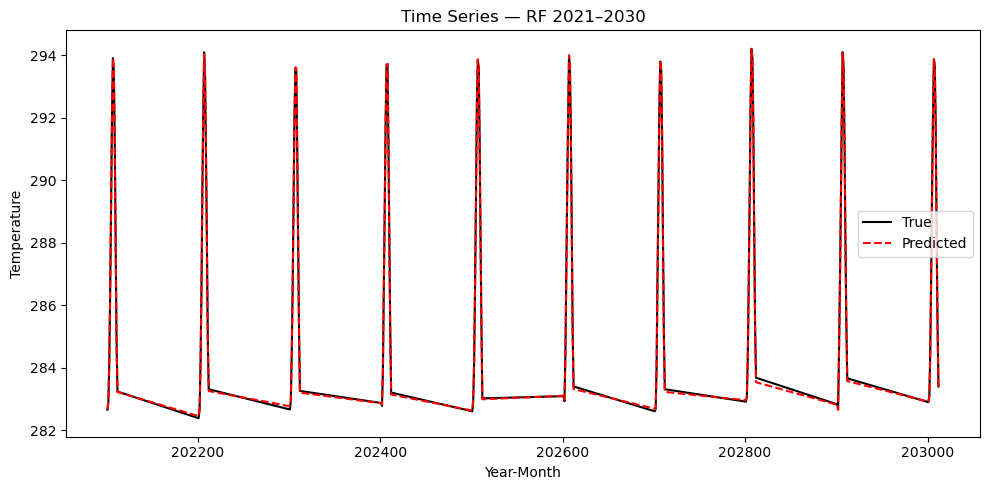

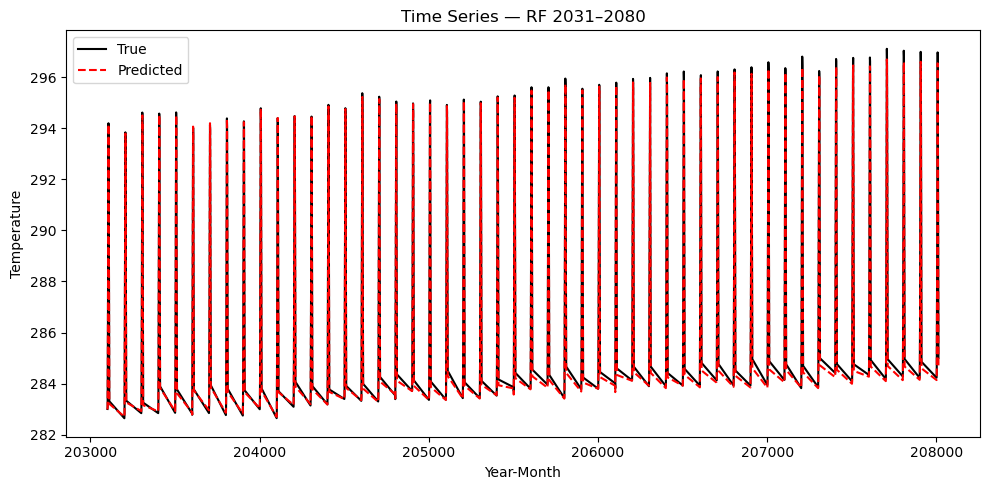

In [ ]:
plot_time_series("rf_monthly.pkl", X_test1, y_test1, df_test1, "RF 2021–2030")
plot_time_series("rf_monthly.pkl", X_test6, y_test6, df_test6, "RF 2031–2080")

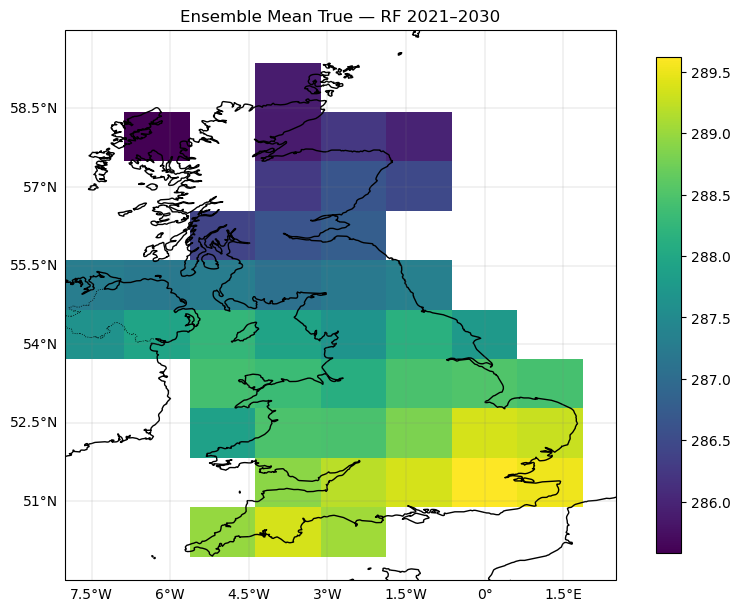

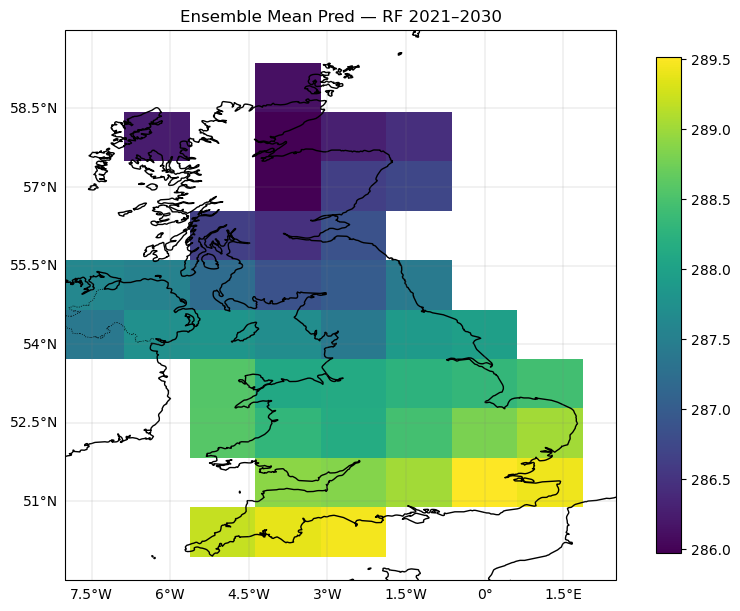

In [ ]:
# Trure map 
plot_map("rf_monthly.pkl", X_test1, y_test1, df_test1, "RF 2021–2030", kind="true")

# Prediction map 
plot_map("rf_monthly.pkl", X_test1, y_test1, df_test1, "RF 2021–2030", kind="pred")

RMSE color scale: 0.3 0.9656280400647931


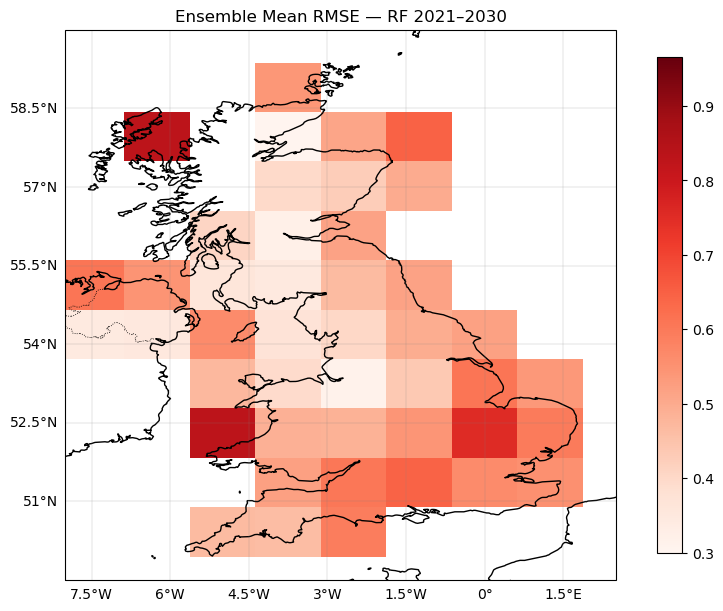

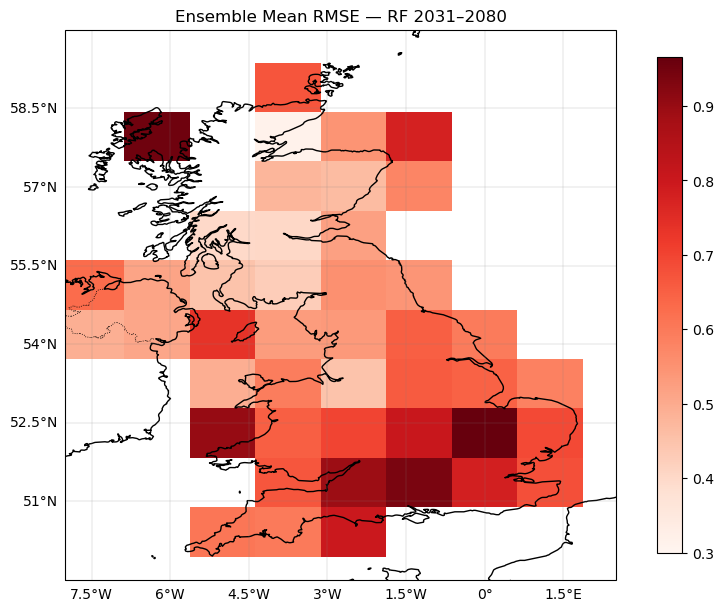

In [ ]:
# Calculate RMSE grids for two time periods
G1 = rmse_grid("rf_monthly.pkl", X_test1, y_test1, df_test1)  # 2021–2030
G2 = rmse_grid("rf_monthly.pkl", X_test6, y_test6, df_test6)  # 2031–2080

# 2) Determine vmin/vmax for color scale
vmin = 0.3
vmax = max(np.nanquantile(G1, 0.98), np.nanquantile(G2, 0.98)) # 98th percentile for better visualisation

print("RMSE color scale:", vmin, vmax)

# Plot
plot_map("rf_monthly.pkl", X_test1, y_test1, df_test1,
         "RF 2021–2030", kind="rmse", vmin=vmin, vmax=vmax)

plot_map("rf_monthly.pkl", X_test6, y_test6, df_test6,
         "RF 2031–2080", kind="rmse", vmin=vmin, vmax=vmax)

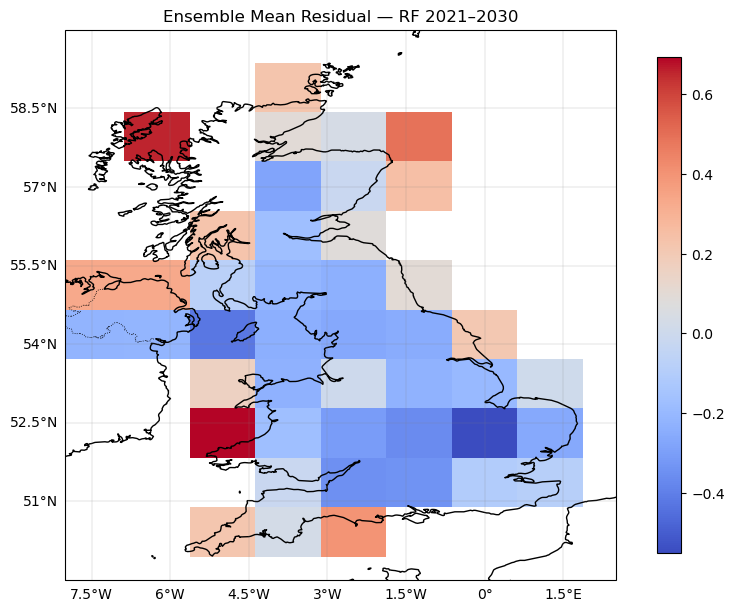

In [ ]:
# Residual map
plot_map("rf_monthly.pkl", X_test1, y_test1, df_test1, "RF 2021–2030", kind="residual")

## Step 7 — Feature importance (Random Forest)

In [ ]:
with open("rf_monthly.pkl","rb") as f:
    rf = pickle.load(f) 

names = rf.feature_names_in_ 
imp   = rf.feature_importances_.astype(float)

df = (pd.DataFrame({"feature": names, "gini": imp, "gini_%": imp/imp.sum()*100})
        .sort_values("gini", ascending=False).reset_index(drop=True))
print("Feature importance (monthly):")
print(df.to_string(index=False))


Feature importance (monthly):
feature         gini    gini_%
 TREFHT 6.922910e-01 69.229102
   QBOT 2.034619e-01 20.346186
   FSNS 8.203179e-02  8.203179
   FLNS 8.915278e-03  0.891528
   UBOT 8.159413e-03  0.815941
   VBOT 5.140598e-03  0.514060
  PRECT 3.149570e-08  0.000003
   PRSN 0.000000e+00  0.000000
